In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import os

base_path = "../Daten"

all_measurements = []  
measurement_id = 0      

for folder in os.listdir(base_path):
    folder_path = os.path.join(base_path, folder)
    
    # Nur Unterordner nehmen
    if os.path.isdir(folder_path):
        
        try:
            # CSVs laden
            acceleration = pd.read_csv(os.path.join(folder_path, "Accelerometer.csv"))
            gyroscope = pd.read_csv(os.path.join(folder_path, "Gyroscope.csv"))
            tag = pd.read_csv(os.path.join(folder_path, "Tags.csv"))
            
            
            acceleration["Sensor"] = "Accelerometer"
            gyroscope["Sensor"] = "Gyroscope"
            
            data = pd.concat([acceleration, gyroscope], ignore_index=True)
            
            # Zeit konvertieren 
            data["time"] = pd.to_datetime(data["time"])
            
            # Tag setzen
            data["Tag"] = tag["tag"].iloc[0]
            
            # Messungs-ID setzen
            data["ID"] = measurement_id
            
            measurement_id += 1
            
            # Speichern
            all_measurements.append(data)
        
        except Exception as e:
            print(f"Fehler in Ordner {folder}: {e}")

# Alle Messungen zusammenführen
final_df = pd.concat(all_measurements, ignore_index=True)


Fehler in Ordner 2026-03-15_15-40-14: [Errno 2] No such file or directory: '../Daten\\2026-03-15_15-40-14\\Accelerometer.csv'
Fehler in Ordner 2026-03-16_06-26-43: [Errno 2] No such file or directory: '../Daten\\2026-03-16_06-26-43\\Accelerometer.csv'
Fehler in Ordner 2026-03-16_06-28-10: [Errno 2] No such file or directory: '../Daten\\2026-03-16_06-28-10\\Accelerometer.csv'
Fehler in Ordner 2026-03-16_06-30-57: [Errno 2] No such file or directory: '../Daten\\2026-03-16_06-30-57\\Accelerometer.csv'
Fehler in Ordner 2026-03-16_06-34-08: [Errno 2] No such file or directory: '../Daten\\2026-03-16_06-34-08\\Accelerometer.csv'
Fehler in Ordner 2026-03-16_06-35-44: [Errno 2] No such file or directory: '../Daten\\2026-03-16_06-35-44\\Accelerometer.csv'
Fehler in Ordner 2026-03-16_06-37-42: [Errno 2] No such file or directory: '../Daten\\2026-03-16_06-37-42\\Accelerometer.csv'
Fehler in Ordner 2026-03-16_06-51-32: [Errno 2] No such file or directory: '../Daten\\2026-03-16_06-51-32\\Acceleromet

In [4]:
# trim the first 3 seconds and the last 3
def trim_measurement(group, trim_seconds=3):
    min_time = group["seconds_elapsed"].min()
    max_time = group["seconds_elapsed"].max()
    return group.loc[
        (group["seconds_elapsed"] >= min_time + trim_seconds) &
        (group["seconds_elapsed"] <= max_time - trim_seconds)
    ]

# ID als separate Spalte sichern bevor groupby sie verschluckt
final_df["ID_backup"] = final_df["ID"]

df = (
    final_df
    .groupby("ID_backup", group_keys=False)
    .apply(trim_measurement)
    .reset_index(drop=True)
)


In [5]:
df.shape

(3459003, 8)

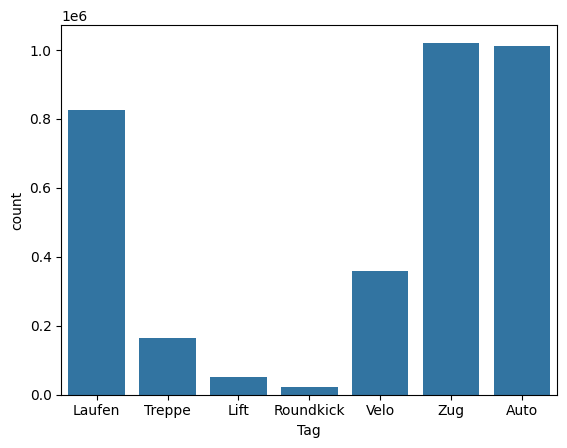

In [6]:
sns.countplot(df, x="Tag")
plt.show()

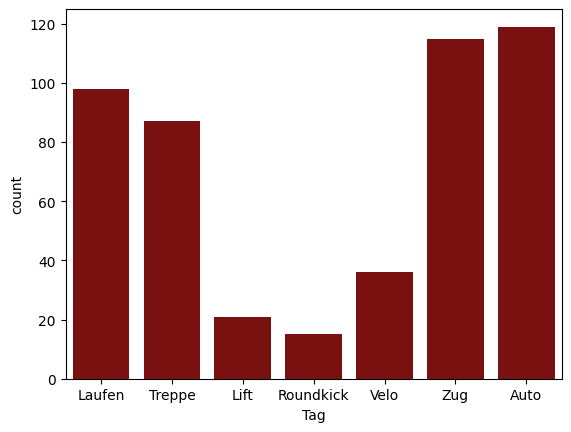

In [7]:
# Eine Zeile pro ID behalten, dann Tags zählen
df_unique = df.drop_duplicates(subset="ID")[["ID", "Tag"]]

sns.countplot(df_unique, x="Tag", color="darkred")
plt.show()